In [1]:
# CELDA 1
# RENABAP · Análisis 1 — Universo y evolución (AMT)
# BLOQUE 1: Carga + armonización + geometría
# Entorno: Google Colab | Fuente de datos: repo GitHub Camilamop/RENABAP

import os
REPO_URL = "https://github.com/Camilamop/RENABAP.git"

if os.path.exists('/content/RENABAP'):
    !cd /content/RENABAP && git fetch origin && git reset --hard origin/master
else:
    !git clone {REPO_URL} /content/RENABAP

!pip install geopandas --quiet


Cloning into '/content/RENABAP'...
remote: Enumerating objects: 187, done.
remote: Counting objects: 100% (187/187), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 187 (delta 74), reused 148 (delta 41), pack-reused 0 (from 0)
Receiving objects: 100% (187/187), 8.76 MiB | 10.07 MiB/s, done.
Resolving deltas: 100% (74/74), done.


In [2]:
!pip install geopandas --quiet

In [3]:
# CELDA 2
import pandas as pd
import geopandas as gpd
from shapely import wkt as shapely_wkt
from pathlib import Path

RAIZ = Path("/content/RENABAP")
DIR_DATOS  = RAIZ / "data" / "raw"
DIR_SALIDA = RAIZ / "data" / "processed"
DIR_SALIDA.mkdir(parents=True, exist_ok=True)

CRS_ORIGEN = "EPSG:4326"

In [4]:
# CELDA 3
# Diccionario de armonización + esquema núcleo + ARCHIVOS
# nombre_original -> nombre_núcleo
MAPEO = {
    2018: {
        "id_renabap": "id_renabap",
        "Nombre del barrio": "nombre_barrio",
        "Nombre de provincia": "provincia",
        "Nombre de departamentos/comuna": "departamento",
        "Localidad": "localidad",
        "Cantidad de familias": "cant_familias",
        "Tamaño (km2)": "superficie_km2",
        "Año de creación": "anio_creacion",
        "Clasificación del barrio": "clasificacion_cod",
        "WKT": "wkt",
    },
    2022: {
        "renabap_id": "id_renabap",
        "nombre_barrio": "nombre_barrio",
        "provincia": "provincia",
        "departamento": "departamento",
        "localidad": "localidad",
        "cantidad_familias_aproximada": "cant_familias",
        "superficie_m2": "superficie_m2",
        "decada_de_creacion": "decada_creacion",
        "cantidad_viviendas_aproximadas": "cant_viviendas",
        "clasificacion_barrio": "clasificacion",
        "WKT": "wkt",
    },
    2023: {
        "id_renabap": "id_renabap",
        "nombre_barrio": "nombre_barrio",
        "provincia": "provincia",
        "departamento": "departamento",
        "localidad": "localidad",
        "cantidad_familias_aproximada": "cant_familias",
        "superficie_m2": "superficie_m2",
        "decada_de_creacion": "decada_creacion",
        "cantidad_viviendas_aproximadas": "cant_viviendas",
        "clasificacion_barrio": "clasificacion",
        "WKT": "wkt",
    },
}

NUCLEO = [
    "id_renabap", "registro", "nombre_barrio", "provincia", "departamento",
    "localidad", "cant_familias", "superficie_ha","cant_viviendas",
    "anio_creacion", "decada_creacion", "clasificacion", "wkt",
]

ARCHIVOS = {
    2018: DIR_DATOS / "RENABAP_2018.csv",
    2022: DIR_DATOS / "RENABAP_2022.csv",
    2023: DIR_DATOS / "RENABAP_2023.csv",
}


In [5]:
# CELDA 3B — Diccionario de valores 2018 (poblaciones.org)
import csv

def cargar_diccionario(path):
    """Parsea el diccionario por bloques -> {variable: {codigo: etiqueta}}."""
    mapas, var, en_valores = {}, None, False
    with open(path, encoding="utf-8") as f:
        for row in csv.reader(f):
            if not row or all(c.strip() == "" for c in row):
                en_valores = False; continue
            k = row[0].strip(); v = row[1].strip() if len(row) > 1 else ""
            if k == "Variable:":
                var = v; en_valores = False
            elif k == "Valores":
                en_valores = True; mapas[var] = {}
            elif en_valores and var is not None:
                mapas[var][k] = v
    return mapas

DICC_2018 = cargar_diccionario(DIR_DATOS / "RENABAP_2018_diccionario.csv")
print("Variables codificadas:", list(DICC_2018))
print("clasificacion:", DICC_2018["clasificacion"])

Variables codificadas: ['origen', 'decada_creacion', 'clasificacion', 'situacion_dominial', 'tipo_tierra', 'tipo_estado_tierras_recodificada', 'electricidad', 'cloacas', 'agua', 'cocina', 'calefaccion', 'precariedad']
clasificacion: {'1': 'Asentamiento', '2': 'Villa'}


In [6]:
# CELDA 4
# Funciones de carga y armonización

def cargar_crudo(anio: int, ruta: Path) -> pd.DataFrame:
    df = pd.read_csv(ruta, dtype=str, keep_default_na=False, encoding="utf-8")
    df.columns = [c.strip() for c in df.columns]
    return df


def normalizar_decada(serie_cruda: pd.Series) -> pd.Series:
    s = serie_cruda.astype(str).str.extract(r"(\d{4})")[0]
    return pd.to_numeric(s, errors="coerce").astype("Int64")

def colapsar_clasificacion(serie: pd.Series) -> pd.Series:
    s = serie.astype("string").str.strip()
    fuera = ~s.isin(["Asentamiento", "Villa","Conjunto habitacional unifamiliar", "Conjunto habitacional degradado"]) & s.notna()
    return s.mask(fuera, "Otros")

def armonizar(anio: int, df: pd.DataFrame) -> pd.DataFrame:
    mapa = MAPEO[anio]

    cols_presentes = {orig: nuevo for orig, nuevo in mapa.items() if orig in df.columns}
    out = df[list(cols_presentes.keys())].rename(columns=cols_presentes).copy()

    # registro (edición del registro)
    out["registro"] = anio

    # id como texto limpio
    out["id_renabap"] = out["id_renabap"].str.strip()

    # decodificar clasificación 2018 (código numérico -> etiqueta, vía diccionario)
    if "clasificacion_cod" in out.columns:
        out["clasificacion"] = (out["clasificacion_cod"].astype(str).str.strip()
                            .map(DICC_2018["clasificacion"]))
        out = out.drop(columns=["clasificacion_cod"])

    # superficie a hectáreas (2022/2023 vienen en m²; 2018 viene en km²)
    if "superficie_m2" in out.columns:
        out["superficie_ha"] = pd.to_numeric(out["superficie_m2"], errors="coerce") / 10_000
        out = out.drop(columns=["superficie_m2"])
    elif "superficie_km2" in out.columns:
        out["superficie_ha"] = pd.to_numeric(out["superficie_km2"], errors="coerce") * 100
        out = out.drop(columns=["superficie_km2"])

    # cantidad de familias -> numérico
    if "cant_familias" in out.columns:
        out["cant_familias"] = pd.to_numeric(out["cant_familias"], errors="coerce").astype("Int64")

    if "cant_viviendas" in out.columns:
        out["cant_viviendas"] = pd.to_numeric(out["cant_viviendas"], errors="coerce").astype("Int64")

    # año de creación -> numérico (solo 2018 lo trae confiable)
    if "anio_creacion" in out.columns:
        anio_num = pd.to_numeric(out["anio_creacion"], errors="coerce")
        anio_num = anio_num.where((anio_num >= 1800) & (anio_num <= 2025))
        out["anio_creacion"] = anio_num.astype("Int64")
    else:
        out["anio_creacion"] = pd.array([pd.NA] * len(out), dtype="Int64")


    if "decada_creacion" in out.columns:
        out["decada_creacion"] = normalizar_decada(out["decada_creacion"])
    else:
        out["decada_creacion"] = (out["anio_creacion"] // 10 * 10).astype("Int64")

    # localidad: garantizar la columna aunque alguna edición no la trajera
    if "localidad" not in out.columns:
        out["localidad"] = pd.NA

    # reordenar a esquema núcleo (agrega faltantes como NA, p.ej. 'wkt' en 2023)
    for c in NUCLEO:
        if c not in out.columns:
            out[c] = pd.NA
    return out[NUCLEO]


def a_geodataframe(df: pd.DataFrame) -> gpd.GeoDataFrame:
    """Parsea el WKT a geometría y arma un GeoDataFrame en EPSG:4326."""
    geom = df["wkt"].apply(lambda w: shapely_wkt.loads(w) if isinstance(w, str) and w.strip() else None)
    gdf = gpd.GeoDataFrame(df.drop(columns=["wkt"]), geometry=geom, crs=CRS_ORIGEN)
    return gdf


In [7]:
# CELDA 5
# Ejecución
def main():
    piezas = []
    print("Cargando y armonizando los tres registros...\n")
    for anio, ruta in ARCHIVOS.items():
        crudo = cargar_crudo(anio, ruta)
        arm = armonizar(anio, crudo)
        piezas.append(arm)
        n_geom = arm["wkt"].apply(lambda w: isinstance(w, str) and w.strip() != "").sum()
        print(f"  {anio}: {len(arm):>5} barrios | geometrías no vacías: {n_geom}")

    maestra = pd.concat(piezas, ignore_index=True)
    maestra["clasificacion"] = colapsar_clasificacion(maestra["clasificacion"])
    gdf = a_geodataframe(maestra)
    invalidas = gdf.geometry.isna().sum()

    print(f"\nTabla maestra (largo): {len(maestra)} filas "
          f"{maestra['registro'].value_counts().sort_index().to_dict()}")
    print(f"Geometrías que no parsearon o faltan: {invalidas}")

    # CSV de atributos (sin geometría)
    maestra.drop(columns=["wkt"]).to_csv(DIR_SALIDA / "renabap_maestra_largo.csv", index=False)

    # FIX: escritura robusta del GPKG por capas (sin pisar capas ni romper con capa vacía)
    gpkg_path = DIR_SALIDA / "renabap_nacional.gpkg"
    if gpkg_path.exists():
        gpkg_path.unlink()
    primera = True
    for anio in ARCHIVOS:
        sub = gdf[(gdf["registro"] == anio) & gdf.geometry.notna()]
        if len(sub) == 0:
            print(f"  [AVISO] {anio}: sin geometrías -> no se escribe capa en el GPKG.")
            continue
        sub.to_file(gpkg_path, layer=f"renabap_{anio}", driver="GPKG",
                    mode="w" if primera else "a")
        primera = False

    print(f"\nExportado en: {DIR_SALIDA.resolve()}")
    print("  - renabap_maestra_largo.csv")
    print("  - renabap_nacional.gpkg (una capa por edición con geometría disponible)")

    print("\n--- Familias totales por registro (nacional) ---")
    print(maestra.groupby("registro")["cant_familias"].agg(["count", "sum"]))
    print("\n--- Cobertura de 'década de creación' por registro ---")
    print(maestra.groupby("registro")["decada_creacion"].apply(lambda s: round(s.notna().mean(), 3)))
    print("\n--- Cobertura de 'localidad' por registro ---")
    print(maestra.groupby("registro")["localidad"].apply(
        lambda s: round((s.notna() & (s.astype(str).str.strip() != "")).mean(), 3)))

    # aviso explícito si algún año quedó sin geometría (hoy: 2023)
    sin_geo = [a for a in ARCHIVOS if gdf[(gdf["registro"] == a) & gdf.geometry.notna()].empty]
    if sin_geo:
        print("\n" + "="*60)
        print(f"⚠️  SIN GEOMETRÍA: {sin_geo}. Para el recorte AMT y los mapas")
        print("    necesitás la versión con polígonos de esa(s) edición(es)")
        print("    (GeoJSON/SHP/GPKG oficial o CSV con columna WKT) en data/raw/.")
        print("="*60)

    return maestra, gdf


maestra, gdf = main()


Cargando y armonizando los tres registros...

  2018:  4416 barrios | geometrías no vacías: 4416
  2022:  5687 barrios | geometrías no vacías: 5687
  2023:  6467 barrios | geometrías no vacías: 6467


/tmp/ipykernel_6848/1605164390.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  maestra = pd.concat(piezas, ignore_index=True)



Tabla maestra (largo): 16570 filas {2018: 4416, 2022: 5687, 2023: 6467}
Geometrías que no parsearon o faltan: 0

Exportado en: /content/RENABAP/data/processed
  - renabap_maestra_largo.csv
  - renabap_nacional.gpkg (una capa por edición con geometría disponible)

--- Familias totales por registro (nacional) ---
          count      sum
registro                
2018       4416   925609
2022       5687  1165275
2023       6467  1237795

--- Cobertura de 'década de creación' por registro ---
registro
2018    0.679
2022    1.000
2023    1.000
Name: decada_creacion, dtype: float64

--- Cobertura de 'localidad' por registro ---
registro
2018    1.0
2022    1.0
2023    1.0
Name: localidad, dtype: float64


In [8]:
# CELDA 6
# Imports, rutas y parámetros
import re
import pandas as pd
import geopandas as gpd
from pathlib import Path

RAIZ       = Path("/content/RENABAP")
DIR_PROC   = RAIZ / "data" / "processed"
DIR_QGIS   = DIR_PROC / "qgis"
GPKG_NAC   = DIR_PROC / "renabap_nacional.gpkg"
LIMITE_PATH = RAIZ / "data" / "raw" / "limite_amt.gpkg"

ANIOS      = [2018, 2022, 2023]
CRS_DATOS  = "EPSG:4326"   # almacenamiento / recorte
CRS_METRICO = "EPSG:5345"  # POSGAR 2007 Faja 3 para áreas/distancias

# Conteos de tus recortes de QGIS (referencia de corroboración)
QGIS_REF = {2018: 144, 2022: 170, 2023: 213}


In [9]:
# CELDA 6 — Barrios, familias y superficie (ha) por PROVINCIA y por registro (nacional)
# Trabaja sobre 'maestra'. Correr después de la CELDA 5.
from google.colab import data_table
from IPython.display import display

if "maestra" not in globals():
    raise NameError("Falta 'maestra'. Corré la CELDA 5 antes de esta.")

prov = maestra.copy()
prov["provincia"] = prov["provincia"].astype(str).str.strip()

# Homogeneizar el único rótulo que cambia entre ediciones
prov["provincia"] = prov["provincia"].replace({
    "Tierra del Fuego, Antártida e Islas del Atlántico Sur": "Tierra del Fuego",
})

# --- Formato largo (tidy): provincia × registro con las tres métricas ---
tabla_prov = (prov.groupby(["provincia", "registro"])
                  .agg(barrios=("id_renabap", "count"),
                       familias=("cant_familias", "sum"),
                       superficie_ha=("superficie_ha", "sum"))
                  .round({"superficie_ha": 1})
                  .reset_index()
                  .sort_values(["provincia", "registro"]))

print("Barrios, familias y superficie (ha) por provincia y registro — Nacional (formato largo)")
display(data_table.DataTable(tabla_prov, num_rows_per_page=25, include_index=False))

# --- Vista ancha: comparación lado a lado entre registros ---
ancha = tabla_prov.pivot(index="provincia", columns="registro",
                         values=["barrios", "familias", "superficie_ha"])
ancha.columns = [f"{m}_{r}" for m, r in ancha.columns]      # aplano el MultiIndex
col_orden = next((c for c in [f"barrios_{a}" for a in (2023, 2022, 2018)]
                  if c in ancha.columns), None)
if col_orden:
    ancha = ancha.sort_values(col_orden, ascending=False)   # provincias más grandes arriba
ancha = ancha.reset_index()
metric_cols = [c for c in ancha.columns if c != "provincia"]

fila_total = {"provincia": "— TOTAL NACIONAL —"}
for c in metric_cols:
    v = ancha[c].sum()
    fila_total[c] = round(float(v), 1) if c.startswith("superficie") else int(v)

ancha_tot = pd.concat([ancha, pd.DataFrame([fila_total])], ignore_index=True)

print("Vista ancha con total — provincia × registro (barrios / familias / superficie ha)")
display(data_table.DataTable(ancha_tot, num_rows_per_page=30, include_index=False))

print("Vista ancha — provincia × registro (barrios / familias / superficie ha)")
display(data_table.DataTable(ancha, num_rows_per_page=25, include_index=False))

Barrios, familias y superficie (ha) por provincia y registro — Nacional (formato largo)


,provincia,registro,barrios,familias,superficie_ha
0,Buenos Aires,2018,1727,484058,19921.0
1,Buenos Aires,2022,1933,571028,23429.0
2,Buenos Aires,2023,2065,588779,25773.3
3,Catamarca,2018,32,3225,142.1
4,Catamarca,2022,41,2885,178.2
...,...,...,...,...,...
67,Tierra del Fuego,2022,47,6014,732.9
68,Tierra del Fuego,2023,49,6147,755.7
69,Tucumán,2018,203,34847,1354.3
70,Tucumán,2022,298,45071,2143.5


Vista ancha con total — provincia × registro (barrios / familias / superficie ha)


,provincia,barrios_2018,barrios_2022,barrios_2023,familias_2018,familias_2022,familias_2023,superficie_ha_2018,superficie_ha_2022,superficie_ha_2023
0,Buenos Aires,1727,1933,2065,484058,571028,588779,19921.0,23429.0,25773.3
1,Santa Fe,340,408,469,72402,87231,92776,2726.7,3359.8,3787.4
2,Chaco,263,401,442,32570,51246,55821,2540.9,4002.8,4628.8
3,Misiones,268,375,413,41181,55747,58322,3957.3,5180.0,5518.7
4,Tucumán,203,298,370,34847,45071,48003,1354.3,2143.5,2437.3
5,Mendoza,247,317,360,16585,24155,26432,1312.6,2087.1,2405.7
6,Salta,154,233,354,20195,30463,39319,1105.4,1886.6,3194.5
7,Córdoba,194,281,318,23030,34847,37039,1370.8,1910.6,2122.4
8,Corrientes,120,200,257,17956,25552,29136,1324.2,1693.2,2042.7
9,Río Negro,151,208,240,18649,28606,36239,1580.5,2423.2,2758.7


Vista ancha — provincia × registro (barrios / familias / superficie ha)


,provincia,barrios_2018,barrios_2022,barrios_2023,familias_2018,familias_2022,familias_2023,superficie_ha_2018,superficie_ha_2022,superficie_ha_2023
0,Buenos Aires,1727,1933,2065,484058,571028,588779,19921.0,23429.0,25773.3
1,Santa Fe,340,408,469,72402,87231,92776,2726.7,3359.8,3787.4
2,Chaco,263,401,442,32570,51246,55821,2540.9,4002.8,4628.8
3,Misiones,268,375,413,41181,55747,58322,3957.3,5180.0,5518.7
4,Tucumán,203,298,370,34847,45071,48003,1354.3,2143.5,2437.3
5,Mendoza,247,317,360,16585,24155,26432,1312.6,2087.1,2405.7
6,Salta,154,233,354,20195,30463,39319,1105.4,1886.6,3194.5
7,Córdoba,194,281,318,23030,34847,37039,1370.8,1910.6,2122.4
8,Corrientes,120,200,257,17956,25552,29136,1324.2,1693.2,2042.7
9,Río Negro,151,208,240,18649,28606,36239,1580.5,2423.2,2758.7


In [10]:
# CELDA 7
# Cargar el límite, disolver a una sola geometría y alinear CRS
limite = gpd.read_file(LIMITE_PATH)
limite = limite.to_crs(CRS_DATOS)

# geometría única (marco fijo). union_all() en versiones nuevas; unary_union en las previas.
try:
    LIMITE_GEOM = limite.geometry.union_all()
except AttributeError:
    LIMITE_GEOM = limite.geometry.unary_union

area_ha = gpd.GeoSeries([LIMITE_GEOM], crs=CRS_DATOS).to_crs(CRS_METRICO).area.iloc[0] / 1e6
print(f"Límite disuelto: {LIMITE_GEOM.geom_type} | superficie ≈ {area_ha:,.1f} ha (medida en {CRS_METRICO})")


/usr/local/lib/python3.13/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'limite_amt.gpkg': 'amt_mascara' (default), 'limite_amt'. Specify layer parameter to avoid this warning.
  result = read_func(


Límite disuelto: Polygon | superficie ≈ 560.7 ha (medida en EPSG:5345)


In [11]:
# CELDA 7
# Recorte por 'intersecta' (barrio entero) sobre las tres fotos

GPKG_AMT = DIR_PROC / "renabap_amt.gpkg"
if GPKG_AMT.exists():
    GPKG_AMT.unlink()

piezas = []
primera = True
print("Recortando al AMT (regla: intersecta, barrio entero)\n")
for anio in ANIOS:
    capa = gpd.read_file(GPKG_NAC, layer=f"renabap_{anio}").to_crs(CRS_DATOS)
    sub = capa[capa.intersects(LIMITE_GEOM)].copy()

    ref = QGIS_REF.get(anio)
    marca = "✓" if ref is not None and len(sub) == ref else ("~" if ref else " ")
    print(f"  {anio}: {len(sub):>4} barrios en el AMT   (QGIS={ref})  {marca}")

    piezas.append(sub.drop(columns="geometry"))
    if len(sub):
        sub.to_file(GPKG_AMT, layer=f"renabap_amt_{anio}", driver="GPKG",
                    mode="w" if primera else "a")
        primera = False

maestra_amt = pd.concat(piezas, ignore_index=True)
maestra_amt.to_csv(DIR_PROC / "renabap_amt_maestra_largo.csv", index=False)

print(f"\nExportado en {DIR_PROC.resolve()}:")
print("  - renabap_amt.gpkg (capas renabap_amt_2018/2022/2023)")
print("  - renabap_amt_maestra_largo.csv")

from google.colab import data_table

data_table.DataTable(maestra_amt, num_rows_per_page=20, include_index=False)


Recortando al AMT (regla: intersecta, barrio entero)

  2018:  144 barrios en el AMT   (QGIS=144)  ✓
  2022:  170 barrios en el AMT   (QGIS=170)  ✓
  2023:  213 barrios en el AMT   (QGIS=213)  ✓

Exportado en /content/RENABAP/data/processed:
  - renabap_amt.gpkg (capas renabap_amt_2018/2022/2023)
  - renabap_amt_maestra_largo.csv


,id_renabap,registro,nombre_barrio,provincia,departamento,localidad,cant_familias,superficie_ha,cant_viviendas,anio_creacion,decada_creacion,clasificacion
0,2745,2018,ATE,Tucumán,Capital,San Miguel De Tucumán,650,25.333334,NaN,1986.0,1980.0,Asentamiento
1,2746,2018,Parquecito 2,Tucumán,Capital,San Miguel De Tucumán,40,1.427786,NaN,1992.0,1990.0,Asentamiento
2,2747,2018,Villa 9 de Julio 2,Tucumán,Capital,San Miguel De Tucumán,25,0.385817,NaN,1991.0,1990.0,Asentamiento
3,2748,2018,Sin Nombre,Tucumán,Lules,San Miguel De Tucumán,12,0.572419,NaN,2015.0,2010.0,Asentamiento
4,2749,2018,Francisco 1,Tucumán,Capital,San Miguel De Tucumán,500,16.860015,NaN,2011.0,2010.0,Asentamiento
...,...,...,...,...,...,...,...,...,...,...,...,...
522,6861,2023,Las Cañitas,Tucumán,Tafí Viejo,Los Nogales,110,11.770700,100.0,NaN,1970.0,Asentamiento
523,6863,2023,Pacará Pintado,Tucumán,Cruz Alta,San Andrés,22,1.219600,20.0,NaN,2000.0,Asentamiento
524,6864,2023,Villa Rosario,Tucumán,Lules,Ingenio San Pablo,50,3.400600,45.0,NaN,1990.0,Villa
525,6865,2023,Ampliación 130 viviendas,Tucumán,Capital,San Miguel De Tucumán,21,1.399200,19.0,NaN,2010.0,Asentamiento


In [12]:
# CELDA 8
# Corroboración automática contra tus recortes de QGIS
#   - compara conteo
#   - compara el CONJUNTO de ids (qué barrios sobran/faltan)

def columna_id(df: pd.DataFrame):
    """Encuentra la columna de id_renabap sin importar mayúsculas/espacios/guiones."""
    for c in df.columns:
        if re.sub(r'[^a-z]', '', c.lower()) == "idrenabap":
            return c
    return None

print("Corroboración notebook vs QGIS (regla intersecta)\n")
for anio in ANIOS:
    ruta_q = DIR_QGIS / f"RENABAP_AMT_{anio}.csv"
    ids_nb = set(maestra_amt.loc[maestra_amt["registro"] == anio, "id_renabap"].astype(str).str.strip())

    if not ruta_q.exists():
        print(f"  {anio}: notebook={len(ids_nb)} | (no encuentro el recorte QGIS)")
        continue

    q = pd.read_csv(ruta_q, dtype=str, keep_default_na=False)
    q.columns = [c.strip() for c in q.columns]
    ic = columna_id(q)
    if ic is None:
        print(f"  {anio}: notebook={len(ids_nb)} | QGIS={len(q)} | (QGIS sin columna id -> comparo solo conteo)")
        continue

    ids_q = set(q[ic].astype(str).str.strip())
    solo_nb = ids_nb - ids_q      # barrios que el notebook incluye y QGIS no
    solo_q  = ids_q - ids_nb      # barrios que QGIS incluye y el notebook no
    print(f"  {anio}: notebook={len(ids_nb)} | QGIS={len(ids_q)} | "
          f"solo_notebook={len(solo_nb)} | solo_QGIS={len(solo_q)}")
    if solo_nb:
        print(f"        ej. solo_notebook: {sorted(solo_nb)[:5]}")
    if solo_q:
        print(f"        ej. solo_QGIS:     {sorted(solo_q)[:5]}")

print("\nLectura: solo_QGIS>0 = barrios que tu polígono capturó y el notebook no (revisar borde/CRS).")
print("         solo_notebook>0 = barrios de borde que 'intersecta' suma (esperable si en QGIS usaste 'clip' o recortaste a mano).")


Corroboración notebook vs QGIS (regla intersecta)

  2018: notebook=144 | QGIS=144 | solo_notebook=0 | solo_QGIS=0
  2022: notebook=170 | QGIS=170 | solo_notebook=0 | solo_QGIS=0
  2023: notebook=213 | QGIS=213 | solo_notebook=0 | solo_QGIS=0

Lectura: solo_QGIS>0 = barrios que tu polígono capturó y el notebook no (revisar borde/CRS).
         solo_notebook>0 = barrios de borde que 'intersecta' suma (esperable si en QGIS usaste 'clip' o recortaste a mano).


In [13]:
# CELDA 9
# Comparabilidad temporal + resumen del AMT

print("--- Localidades presentes por foto (dentro del AMT) ---")
sets = {}
for anio in ANIOS:
    locs = set(
        maestra_amt.loc[maestra_amt["registro"] == anio, "localidad"]
        .dropna().astype(str).str.strip()
    )
    locs.discard("")
    sets[anio] = locs
    print(f"  {anio}: {len(locs)} localidades")

# ¿el conjunto de localidades cambia entre fotos? (clave para la comparación 2016/18/21)
base = sets[ANIOS[0]]
for anio in ANIOS[1:]:
    nuevas = sets[anio] - base
    perdidas = base - sets[anio]
    print(f"  {ANIOS[0]}→{anio}: +{len(nuevas)} nuevas / -{len(perdidas)} ausentes",
          f"| nuevas: {sorted(nuevas)}" if nuevas else "")

print("\n--- Resumen por registro (AMT) ---")
resumen = maestra_amt.groupby("registro").agg(
    barrios=("id_renabap", "count"),
    familias=("cant_familias", "sum"),
    superficie_ha=("superficie_ha", "sum"),
)
print(resumen)


--- Localidades presentes por foto (dentro del AMT) ---
  2018: 15 localidades
  2022: 18 localidades
  2023: 20 localidades
  2018→2022: +4 nuevas / -1 ausentes | nuevas: ['Colombres', 'Delfín Gallo', 'Ingenio La Florida', 'Los Nogales']
  2018→2023: +6 nuevas / -1 ausentes | nuevas: ['Colombres', 'Delfín Gallo', 'Ingenio La Florida', 'Lastenia', 'Los Nogales', 'Ranchillos']

--- Resumen por registro (AMT) ---
          barrios  familias  superficie_ha
registro                                  
2018          144     30681    1093.025223
2022          170     36457    1255.995700
2023          213     38134    1366.643200


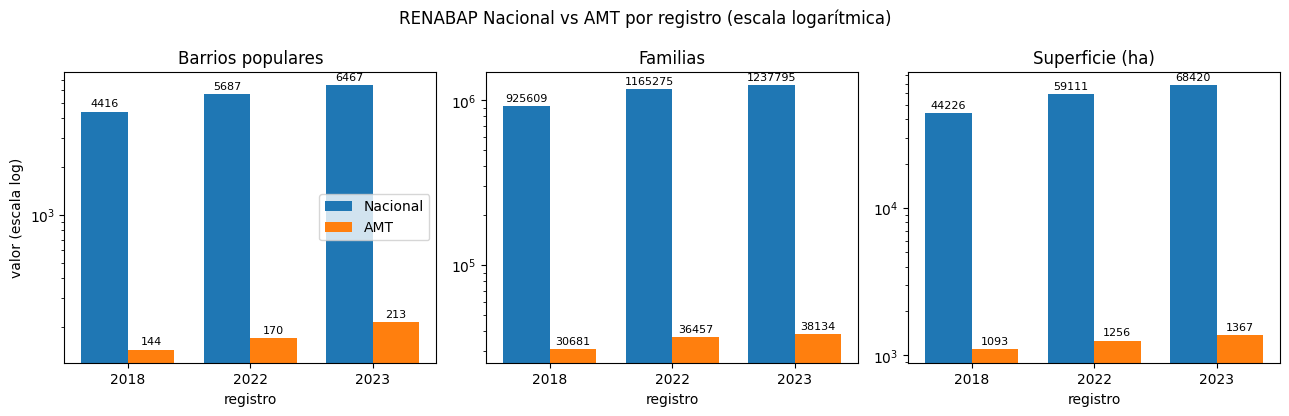

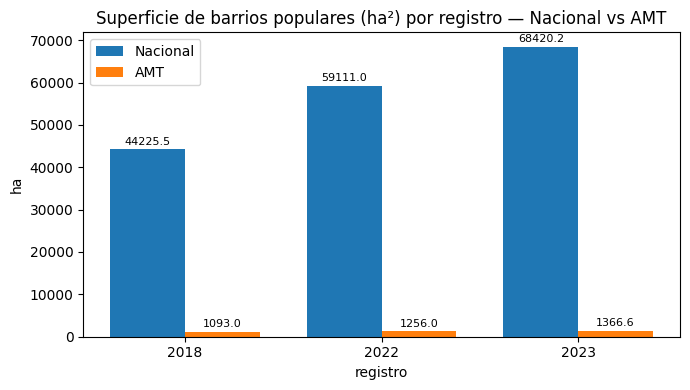

Superficie (ha) por registro — Nacional vs AMT
          nacional_km2  amt_km2  amt_%_nacional
registro                                       
2018           44225.5   1093.0             2.5
2022           59111.0   1256.0             2.1
2023           68420.2   1366.6             2.0


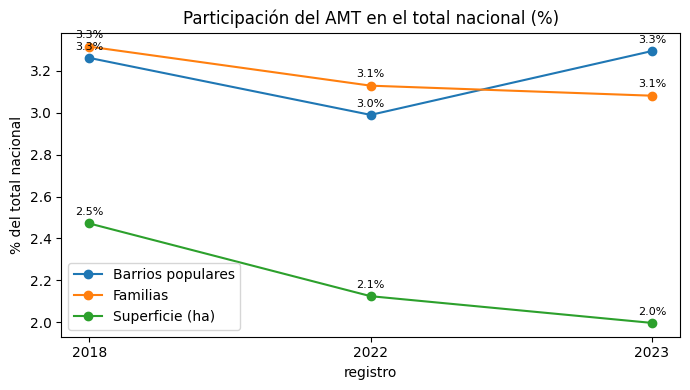

NACIONAL:
           barrios   familias  superficie_ha
registro                                   
2018       4416.0   925609.0       44225.50
2022       5687.0  1165275.0       59111.05
2023       6467.0  1237795.0       68420.19 

AMT:
           barrios  familias  superficie_ha
registro                                  
2018        144.0   30681.0        1093.03
2022        170.0   36457.0        1256.00
2023        213.0   38134.0        1366.64 

Participación AMT (%):
           barrios  familias  superficie_ha
registro                                  
2018         3.26      3.31           2.47
2022         2.99      3.13           2.12
2023         3.29      3.08           2.00


In [14]:
# ============================================================
# CELDA 9B — Comparación gráfica Nacional vs AMT (2018 / 2022 / 2023)
# Métricas: barrios, familias, superficie (ha)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

for _v in ("maestra", "maestra_amt"):
    if _v not in globals():
        raise NameError(f"Falta '{_v}'. Corré la CELDA 5 y el Bloque 2 antes de esta.")

ANIOS = [2018, 2022, 2023]

def totales(df):
    return df.groupby("registro").agg(
        barrios=("id_renabap", "count"),
        familias=("cant_familias", "sum"),
        superficie_ha=("superficie_ha", "sum"),
    ).reindex(ANIOS).astype(float)

nac = totales(maestra)
amt = totales(maestra_amt)

METRICAS = [("barrios", "Barrios populares"),
            ("familias", "Familias"),
            ("superficie_ha", "Superficie (ha)")]

x = np.arange(len(ANIOS))
w = 0.38

# --- Figura 1: absolutos Nacional vs AMT (escala log por la diferencia de magnitud) ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (col, titulo) in zip(axes, METRICAS):
    b1 = ax.bar(x - w/2, nac[col], w, label="Nacional")
    b2 = ax.bar(x + w/2, amt[col], w, label="AMT")
    ax.set_yscale("log")
    ax.set_title(titulo)
    ax.set_xticks(x); ax.set_xticklabels(ANIOS); ax.set_xlabel("registro")
    ax.bar_label(b1, fmt="%.0f", padding=2, fontsize=8)
    ax.bar_label(b2, fmt="%.0f", padding=2, fontsize=8)
axes[0].set_ylabel("valor (escala log)")
axes[0].legend()
fig.suptitle("RENABAP Nacional vs AMT por registro (escala logarítmica)")
plt.tight_layout(); plt.show()

# --- Superficie (ha²): foco Nacional vs AMT, escala lineal ---
fig3, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - w/2, nac["superficie_ha"], w, label="Nacional")
b2 = ax.bar(x + w/2, amt["superficie_ha"], w, label="AMT")
ax.set_title("Superficie de barrios populares (ha²) por registro — Nacional vs AMT")
ax.set_xticks(x); ax.set_xticklabels(ANIOS); ax.set_xlabel("registro"); ax.set_ylabel("ha")
ax.bar_label(b1, fmt="%.1f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.1f", padding=2, fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()

sup = pd.DataFrame({
    "nacional_km2": nac["superficie_ha"].round(1),
    "amt_km2": amt["superficie_ha"].round(1),
    "amt_%_nacional": (amt["superficie_ha"] / nac["superficie_ha"] * 100).round(1),
})
print("Superficie (ha) por registro — Nacional vs AMT")
print(sup)

# --- Figura 2: participación del AMT en el total nacional (%) ---
share = amt / nac * 100
fig2, ax = plt.subplots(figsize=(7, 4))
for col, titulo in METRICAS:
    ax.plot(x, share[col], marker="o", label=titulo)
    for xi, yi in zip(x, share[col]):
        ax.annotate(f"{yi:.1f}%", (xi, yi), textcoords="offset points",
                    xytext=(0, 6), ha="center", fontsize=8)
ax.set_title("Participación del AMT en el total nacional (%)")
ax.set_xticks(x); ax.set_xticklabels(ANIOS); ax.set_xlabel("registro")
ax.set_ylabel("% del total nacional"); ax.legend()
plt.tight_layout(); plt.show()


# Números exactos de apoyo
print("NACIONAL:\n", nac.round(2), "\n\nAMT:\n", amt.round(2), "\n\nParticipación AMT (%):\n", share.round(2))



In [15]:
import pandas as pd
import unicodedata


def normalizar(x):
    """minúscula, sin acentos y sin espacios extra — para poder unir por nombre."""
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    x = "".join(c for c in unicodedata.normalize("NFKD", x) if not unicodedata.combining(c))
    return x


In [16]:
# CELDA 10
nuevas = pd.DataFrame({
    "localidad": ["Colombres", "Delfín Gallo", "Ingenio La Florida",
                  "Los Nogales", "Lastenia", "Ranchillos"],
    "primer_registro": [2022, 2022, 2022, 2022, 2023, 2023],
})

indec_nombre = {
    "Colombres": "Colombres",
    "Delfín Gallo": "Delfín Gallo",
    "Ingenio La Florida": "La Florida",          # INDEC la registra como "La Florida" (incluye el Ingenio)
    "Los Nogales": "Los Nogales",
    "Lastenia": "Lastenia",
    "Ranchillos": "Ranchillos",     # nombre completo del gobierno local en INDEC
}
poblacion_2022 = {
    "Colombres": 6325,
    "Delfín Gallo": 10613,
    "Ingenio La Florida": 5002,
    "Los Nogales": 5188,
    "Lastenia": None,
    "Ranchillos": 8844,
}



In [17]:
# CELDA 11
dep = maestra_amt[["localidad", "departamento"]].copy()
dep["localidad"] = dep["localidad"].astype(str).str.strip()
dep = dep.dropna(subset=["departamento"]).drop_duplicates("localidad")

nuevas["localidad"] = nuevas["localidad"].str.strip()
nuevas = nuevas.merge(dep, on="localidad", how="left")   # <- agrega 'departamento'

# 2) Columnas derivadas
def rango(p):
    if pd.isna(p):
        return "sin dato censal"
    if p < 2000:
        return "< 2.000"
    if p <= 10000:
        return "2.000–10.000"
    return "> 10.000"

nuevas["localidad_INDEC"] = nuevas["localidad"].map(indec_nombre)
nuevas["poblacion_2022"]  = nuevas["localidad"].map(poblacion_2022)
nuevas["rango_tamano"]    = nuevas["poblacion_2022"].map(rango)

# 3) Notas (criterio: localidad = asentamiento censal / mancha urbana)
notas = {
    "Lastenia": ("Sin dato censal como localidad propia: integra la mancha del Gran SMT "
                 "(componente Banda del Río Salí). RENABAP la registra como localidad; "
                 "por hipótesis, dentro del rango 2.000–10.000 (ampliación del universo)."),
    "Ingenio La Florida": "INDEC la registra como 'La Florida' (incluye el Ingenio).",
    "Ranchillos": "Localidad censal 'Ranchillos y San Miguel'.",
}
nuevas["nota"] = nuevas["localidad"].map(notas).fillna("")

# 4) Tabla final
cols = ["localidad", "localidad_INDEC", "departamento",
        "primer_registro", "poblacion_2022", "rango_tamano", "nota"]
tabla = (nuevas[cols]
         .sort_values(["primer_registro", "localidad"])
         .reset_index(drop=True))

print(tabla.to_string(index=False))

from google.colab import data_table

data_table.DataTable(tabla, include_index=False)

         localidad localidad_INDEC departamento  primer_registro  poblacion_2022    rango_tamano                                                                                                                                                                                                               nota
         Colombres       Colombres    Cruz Alta             2022          6325.0    2.000–10.000                                                                                                                                                                                                                   
      Delfín Gallo    Delfín Gallo    Cruz Alta             2022         10613.0        > 10.000                                                                                                                                                                                                                   
Ingenio La Florida      La Florida    Cruz Alta             2022          50

,localidad,localidad_INDEC,departamento,primer_registro,poblacion_2022,rango_tamano,nota
0,Colombres,Colombres,Cruz Alta,2022,6325.0,2.000–10.000,
1,Delfín Gallo,Delfín Gallo,Cruz Alta,2022,10613.0,> 10.000,
2,Ingenio La Florida,La Florida,Cruz Alta,2022,5002.0,2.000–10.000,INDEC la registra como 'La Florida' (incluye e...
3,Los Nogales,Los Nogales,Tafí Viejo,2022,5188.0,2.000–10.000,
4,Lastenia,Lastenia,Cruz Alta,2023,NaN,sin dato censal,Sin dato censal como localidad propia: integra...
5,Ranchillos,Ranchillos,Cruz Alta,2023,8844.0,2.000–10.000,Localidad censal 'Ranchillos y San Miguel'.


In [18]:
# CELDA 12
tabla.to_csv("localidades_nuevas_poblacion_indec2022.csv", index=False, encoding="utf-8-sig")
tabla.to_excel("localidades_nuevas_poblacion_indec2022.xlsx", index=False)
print("Exportado: CSV y XLSX")


Exportado: CSV y XLSX


In [19]:
# CELDA 13
# RENABAP · Análisis comparativo AMT (2018 / 2022 / 2023)
# BLOQUE 3: EDA + comparación entre relevamientos
# Requiere: 'maestra_amt' en memoria (sale del Bloque 2, recorte AMT).

import numpy as np
import pandas as pd
import unicodedata
import matplotlib.pyplot as plt


def normalizar(x):
       if pd.isna(x):
        return ""
       x = str(x).strip().lower()
       return "".join(c for c in unicodedata.normalize("NFKD", x) if not unicodedata.combining(c))




In [20]:
# CELDA 14 — Los dos sets: núcleo (>10.000) vs ampliado (todo)
# ============================================================
# Localidades incorporadas por ampliación del universo registrado.
# Incluye los dos CASOS ESPECIALES (Delfín Gallo: apenas sobre 10.000 en 2022,
# posterior a los relevamientos; Lastenia: sin dato censal como localidad propia).
LOCALIDADES_AGREGADAS = [
    "Colombres", "Delfín Gallo", "Ingenio La Florida",
    "Los Nogales", "Lastenia", "Ranchillos",
]
CASOS_ESPECIALES = ["Delfín Gallo", "Lastenia"]

_agregadas = {normalizar(l) for l in LOCALIDADES_AGREGADAS}
_especiales = {normalizar(l) for l in CASOS_ESPECIALES}

df = maestra_amt.copy()
df["localidad"] = df["localidad"].astype(str).str.strip()
_loc_norm = df["localidad"].map(normalizar)

df["grupo"] = np.where(_loc_norm.isin(_agregadas), "agregada", "núcleo")
df["caso_especial"] = _loc_norm.isin(_especiales)   # marca DG y Lastenia sin partir el análisis

# Los dos sets :
df_ampliado = df.copy()
df_nucleo   = df[df["grupo"] == "núcleo"].copy()

print("Barrios por registro y grupo:")
print(pd.crosstab(df["registro"], df["grupo"], margins=True))


Barrios por registro y grupo:
grupo     agregada  núcleo  All
registro                       
2018             0     144  144
2022             6     164  170
2023            17     196  213
All             23     504  527


In [21]:
# CELDA 15 — Comparación núcleo vs ampliado (dos tablas para consultar/copiar)
from google.colab import data_table
from IPython.display import display

agg = {"barrios": ("id_renabap", "count"), "familias": ("cant_familias", "sum")}
if "cant_viviendas" in df.columns:
    agg["viviendas"] = ("cant_viviendas", "sum")

agg = {"barrios": ("id_renabap", "count"),
       "familias": ("cant_familias", "sum"),
       "superficie_ha": ("superficie_ha", "sum")}

resumen = df.groupby(["registro", "grupo"]).agg(**agg)
if "viviendas" in resumen.columns:
    cobertura = df.groupby("registro")["cant_viviendas"].apply(lambda s: s.notna().any())
    for reg, hay in cobertura.items():
        if not hay:
            resumen.loc[(reg, slice(None)), "viviendas"] = np.nan

# --- Tabla 1: Totales por registro y grupo ---
tabla_totales = resumen.reset_index()
print("Tabla 1 — Totales por registro y grupo")
display(data_table.DataTable(tabla_totales, include_index=False))

# --- Tabla 2: Barrios por localidad y registro ---
sin_loc = _loc_norm == ""
pivot_barrios = df[~sin_loc].pivot_table(index="localidad", columns="registro",
                                         values="id_renabap", aggfunc="count", fill_value=0)
pivot_barrios.columns = [str(c) for c in pivot_barrios.columns]
pivot_barrios["grupo"] = np.where(pivot_barrios.index.map(normalizar).isin(_agregadas),
                                  "agregada", "núcleo")
tabla_localidad = pivot_barrios.sort_values(["grupo", pivot_barrios.columns[-2]],
                                            ascending=[True, False]).reset_index()
print("Tabla 2 — Barrios por localidad y registro")
display(data_table.DataTable(tabla_localidad, include_index=False))


Tabla 1 — Totales por registro y grupo


,registro,grupo,barrios,familias,superficie_ha
0,2018,núcleo,144,30681,1093.025223
1,2022,agregada,6,227,11.951200
2,2022,núcleo,164,36230,1244.044500
3,2023,agregada,17,749,53.299300
4,2023,núcleo,196,37385,1313.343900


Tabla 2 — Barrios por localidad y registro


,localidad,2018,2022,2023,grupo
0,Los Nogales,0,2,4,agregada
1,Colombres,0,1,3,agregada
2,Delfín Gallo,0,1,3,agregada
3,Ranchillos,0,0,3,agregada
4,Ingenio La Florida,0,2,2,agregada
5,Lastenia,0,0,2,agregada
6,San Miguel De Tucumán,71,77,81,núcleo
7,Tafí Viejo,12,20,21,núcleo
8,Alderetes,12,14,20,núcleo
9,Las Talitas,1,9,16,núcleo


Estadísticos — Familias


,registro,count,mean,std,min,25%,50%,75%,max
0,2018,144.0,213.06,308.38,10.0,50.0,110.0,250.0,2500.0
1,2022,170.0,214.45,317.44,9.0,53.5,114.5,235.5,2750.0
2,2023,213.0,179.03,285.33,9.0,44.0,94.0,220.0,2750.0


Estadísticos — Viviendas


,registro,count,mean,std,min,25%,50%,75%,max
0,2018,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022,170.0,194.89,288.61,8.0,48.5,104.0,213.75,2500.0
2,2023,213.0,162.68,259.41,8.0,40.0,85.0,200.00,2500.0


Estadísticos — Superficie (ha)


,registro,count,mean,std,min,25%,50%,75%,max
0,2018,144.0,7.59,10.15,0.32,1.57,4.53,9.14,60.95
1,2022,170.0,7.39,9.81,0.32,1.54,4.31,8.72,60.85
2,2023,213.0,6.42,8.18,0.38,1.50,3.46,8.03,50.86


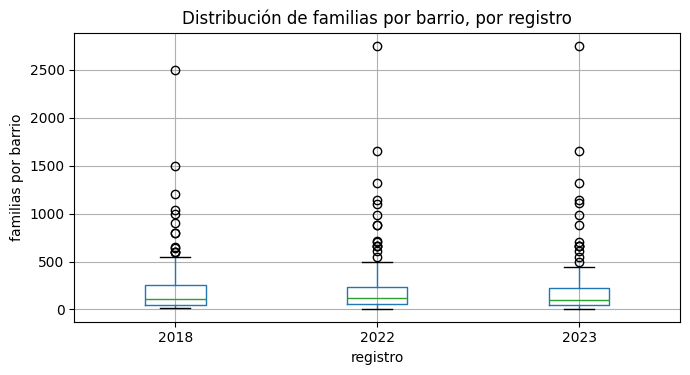

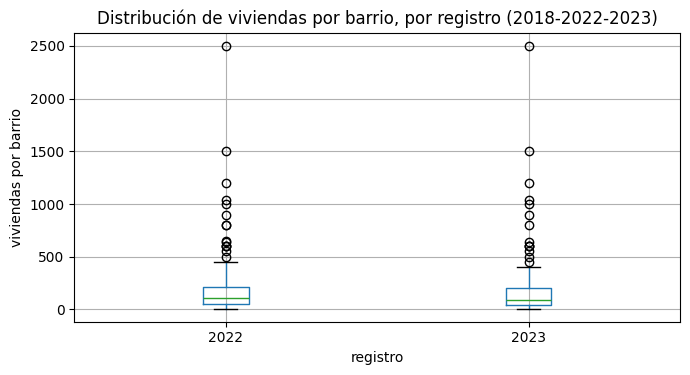

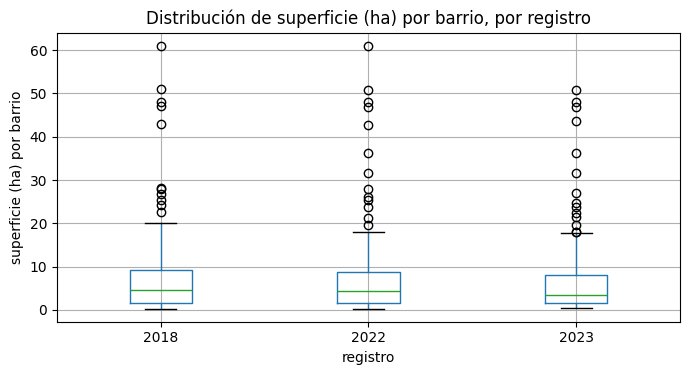

Clasificación del barrio por registro (2018-2022–2023)


registro,clasificacion,2018,2022,2023
0,Asentamiento,124,115,152
1,Conjunto habitacional unifamiliar,0,0,5
2,Villa,20,55,56


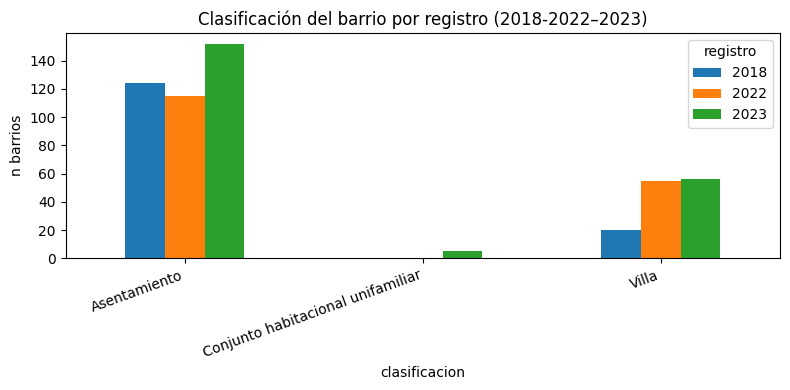

Década de creación por registro (2018-2022–2023)


registro,decada_creacion,2018,2022,2023
0,1900.0,0,3,3
1,1910.0,0,2,7
2,1920.0,0,1,1
3,1930.0,1,1,1
4,1940.0,1,5,6
5,1950.0,0,4,5
6,1960.0,4,7,9
7,1970.0,5,14,16
8,1980.0,15,26,29
9,1990.0,27,42,47


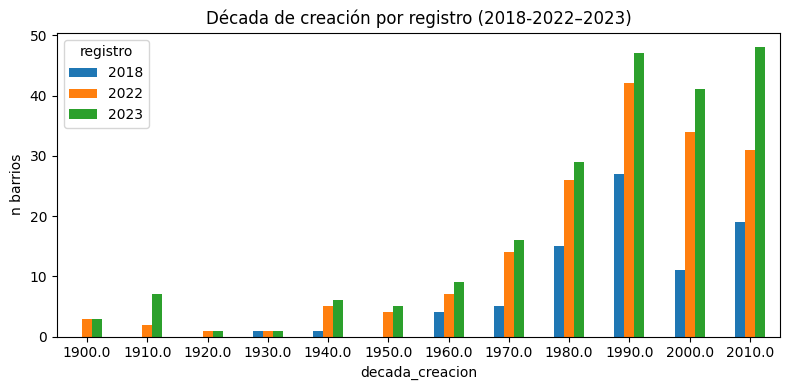

In [22]:
# CELDA 16 — EDA: estadísticos, distribuciones (box) y categóricas
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import data_table
from IPython.display import display

NUM = [("cant_familias", "Familias"),
       ("cant_viviendas", "Viviendas"),
       ("superficie_ha", "Superficie (ha)")]

# --- Estadísticos por registro: una tabla data_table por variable ---
for col, etiqueta in NUM:
    if col not in df.columns:
        print(f"[omito {etiqueta}: falta '{col}']"); continue
    est = (df.assign(**{col: df[col].astype("float")})
             .groupby("registro")[col]
             .describe()[["count","mean","std","min","25%","50%","75%","max"]]
             .round(2).reset_index())
    print(f"Estadísticos — {etiqueta}")
    display(data_table.DataTable(est, include_index=False))

# --- Box plots (misma forma que familias) para las tres numéricas ---
for col, etiqueta in NUM:
    if col not in df.columns:
        continue
    d = df.loc[df[col].notna(), ["registro", col]].copy()
    d[col] = d[col].astype("float")
    if d.empty:
        continue
    d.boxplot(column=col, by="registro", figsize=(7, 4))
    solo = " (2018-2022-2023)" if d["registro"].nunique() < 3 else ""
    plt.title(f"Distribución de {etiqueta.lower()} por barrio, por registro{solo}")
    plt.suptitle(""); plt.ylabel(f"{etiqueta.lower()} por barrio"); plt.xlabel("registro")
    plt.tight_layout(); plt.show()

# --- Categóricas: clasificación y década  ---
df_cat = df[df["registro"].isin([2018, 2022, 2023])]

for col, etiqueta, rot in [("clasificacion", "Clasificación del barrio", 20),
                           ("decada_creacion", "Década de creación", 0)]:
    if col not in df.columns:
        print(f"[{etiqueta}] falta la columna '{col}' en df — revisá el MAPEO."); continue

    serie = df_cat[col].replace("", pd.NA)                 # vacíos = faltantes
    if serie.notna().sum() == 0:                           # existe pero sin datos
        print(f"[{etiqueta}] '{col}' está vacía en df. Re-corré Bloque 1 → Bloque 2 → "
              "celda de los dos sets, con el MAPEO ya parcheado.")
        continue

    ct = pd.crosstab(serie, df_cat["registro"])
    print(f"{etiqueta} por registro (2018-2022–2023)")
    display(data_table.DataTable(ct.reset_index(), include_index=False))

    ct.plot(kind="bar", figsize=(8, 4))
    plt.title(f"{etiqueta} por registro (2018-2022–2023)")
    plt.ylabel("n barrios"); plt.xlabel(col)
    plt.xticks(rotation=rot, ha="right" if rot else "center")
    plt.legend(title="registro"); plt.tight_layout(); plt.show()

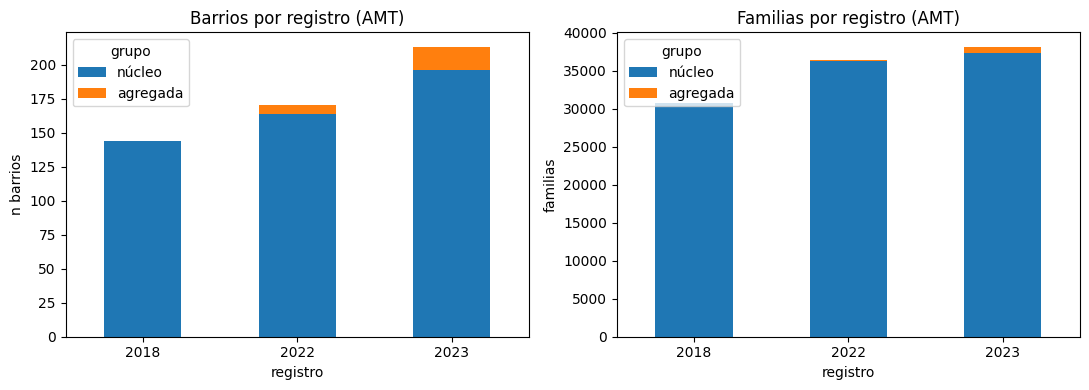

[viviendas] columna ausente: aplicá el parche del Bloque 1 y re-corré para incluirla.


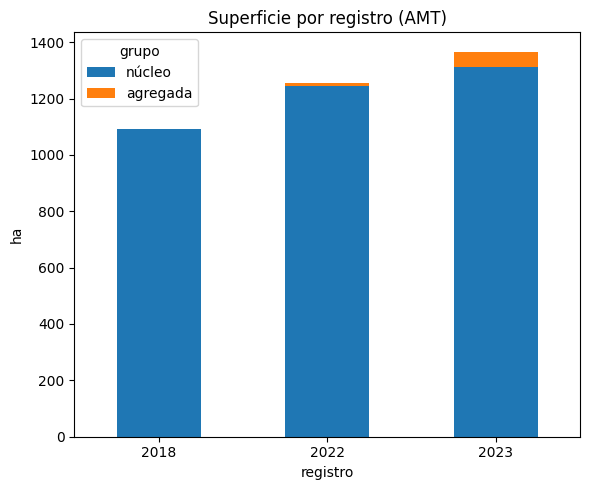

In [23]:
# CELDA 16B
# Gráficos comparativos
def barras_apiladas(col, titulo, ylabel, ax):
    """Apila núcleo + agregadas para ver cuánto del total es ampliación del universo."""
    piv = resumen[col].unstack("grupo")
    for g in ["núcleo", "agregada"]:
        if g not in piv.columns:
            piv[g] = np.nan
    piv[["núcleo", "agregada"]].plot(kind="bar", stacked=True, ax=ax)
    ax.set_title(titulo); ax.set_xlabel("registro"); ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=0)

# Barrios y familias tienen los tres años
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
barras_apiladas("barrios",  "Barrios por registro (AMT)",  "n barrios",  axes[0])
barras_apiladas("familias", "Familias por registro (AMT)", "familias",   axes[1])
plt.tight_layout(); plt.show()

# Viviendas: solo 2022-2023 (2018 no lo releva)
if "viviendas" in resumen.columns:
    piv_v = resumen["viviendas"].unstack("grupo").dropna(how="all")
    for g in ["núcleo", "agregada"]:
        if g not in piv_v.columns:
            piv_v[g] = np.nan
    ax = piv_v[["núcleo", "agregada"]].plot(kind="bar", stacked=True, figsize=(6, 4))
    ax.set_title("Viviendas por registro (AMT) — solo 2022-2023")
    ax.set_xlabel("registro"); ax.set_ylabel("viviendas"); ax.tick_params(axis="x", rotation=0)
    plt.tight_layout(); plt.show()
else:
    print("[viviendas] columna ausente: aplicá el parche del Bloque 1 y re-corré para incluirla.")

# Superficie (ha) por registro — núcleo + agregada (los tres años la tienen)
fig, ax = plt.subplots(figsize=(6, 5))
barras_apiladas("superficie_ha", "Superficie por registro (AMT)", "ha", ax)
plt.tight_layout(); plt.show()



In [24]:
# CELDA 17 — Cambios por barrio entre registros (join por id_renabap)
import pandas as pd
from google.colab import data_table
from IPython.display import display

# --- Alcance y parámetros ---
tabla = maestra_amt
UMBRAL_SUP = 0.10            # superficie: se marca cambio si varía > 10% relativo

def norm_txt(s):
    """Normaliza espacios para no marcar diferencias de puro formato."""
    return (s.dropna().astype(str)
             .str.strip().str.replace(r"\s+", " ", regex=True))

def cambio_cat(s):
    """True si hay >1 valor NO nulo distinto (ignora NA; p. ej. clasificación 2018)."""
    return norm_txt(s).nunique() > 1

g = tabla.groupby("id_renabap")
flags = pd.DataFrame({
    "n_registros":          g["registro"].nunique(),
    "cambio_nombre":        g["nombre_barrio"].apply(cambio_cat),
    "cambio_localidad":     g["localidad"].apply(cambio_cat),
    "cambio_departamento":  g["departamento"].apply(cambio_cat),
    "cambio_clasificacion": g["clasificacion"].apply(cambio_cat),
})

# superficie: variación relativa entre el mín y el máx (solo registros con dato)
sup = (tabla.dropna(subset=["superficie_ha"])
            .groupby("id_renabap")["superficie_ha"].agg(["min", "max", "count"]))
flags["cambio_superficie"] = ((sup["count"] > 1) & (sup["min"] > 0) &
                              ((sup["max"] - sup["min"]) / sup["min"] > UMBRAL_SUP))

cols_cambio = ["cambio_nombre", "cambio_localidad", "cambio_departamento",
               "cambio_superficie", "cambio_clasificacion"]
flags[cols_cambio] = flags[cols_cambio].fillna(False).astype(bool)
flags["n_cambios"] = flags[cols_cambio].sum(axis=1)

# nombre más reciente, para lectura
flags.insert(0, "nombre_barrio",
             tabla.sort_values("registro").groupby("id_renabap")["nombre_barrio"].last())

cambios = (flags[(flags["n_registros"] > 1) & (flags["n_cambios"] > 0)]
           .sort_values(["n_cambios", "id_renabap"], ascending=[False, True])
           .reset_index())

print(f"Barrios comparables (presentes en >1 registro): {(flags['n_registros'] > 1).sum()}")
print(f"Barrios con algún cambio: {len(cambios)}")
for c in cols_cambio:
    print(f"   {c:22s}: {int(flags[c].sum())}")
display(data_table.DataTable(cambios, num_rows_per_page=25, include_index=False))

# --- Detalle: valor por registro, solo para los barrios que cambiaron ese atributo ---
def detalle(attr, flag_col, redondear=None, contexto=None):
    ids = flags.index[flags[flag_col]]
    if len(ids) == 0:
        print(f"[{attr}] sin cambios."); return
    sub = tabla[tabla["id_renabap"].isin(ids)]
    piv = sub.pivot_table(index="id_renabap", columns="registro", values=attr, aggfunc="first")
    if redondear is not None:
        piv = piv.round(redondear)
    piv.columns = [f"{attr}_{c}" for c in piv.columns]
    # columnas de contexto: valor más reciente por barrio (p. ej. localidad)
    if contexto:
        ctx = sub.sort_values("registro").groupby("id_renabap")[contexto].last()
        piv = ctx.join(piv)
    print(f"Detalle — cambios en {attr} ({len(ids)} barrios)")
    display(data_table.DataTable(piv.reset_index(), num_rows_per_page=15, include_index=False))

detalle("nombre_barrio", "cambio_nombre")
detalle("localidad",     "cambio_localidad")
detalle("departamento",  "cambio_departamento")
# --- Superficie con tendencia 2018 → 2023 ---
ids_sup = flags.index[flags["cambio_superficie"]]
if len(ids_sup) == 0:
    print("[superficie_ha] sin cambios.")
else:
    piv_sup = (tabla[tabla["id_renabap"].isin(ids_sup)]
               .pivot_table(index="id_renabap", columns="registro",
                            values="superficie_ha", aggfunc="first")
               .round(1))
    if 2018 in piv_sup.columns and 2023 in piv_sup.columns:
        delta = piv_sup[2023] - piv_sup[2018]
        piv_sup["tendencia_2018_2023"] = delta.map(
            lambda d: "aumenta" if d > 0 else ("disminuye" if d < 0 else "sin cambio"))
        piv_sup.loc[piv_sup[2018].isna() | piv_sup[2023].isna(),
                    "tendencia_2018_2023"] = "sin dato"
    piv_sup.columns = [c if c == "tendencia_2018_2023" else f"superficie_ha_{c}"
                       for c in piv_sup.columns]
    print(f"Detalle — cambios en superficie_ha ({len(ids_sup)} barrios)")
    display(data_table.DataTable(piv_sup.reset_index(), num_rows_per_page=15, include_index=False))
detalle("clasificacion", "cambio_clasificacion", contexto=["localidad"])

Barrios comparables (presentes en >1 registro): 170
Barrios con algún cambio: 98
   cambio_nombre         : 25
   cambio_localidad      : 14
   cambio_departamento   : 6
   cambio_superficie     : 46
   cambio_clasificacion  : 46


,id_renabap,nombre_barrio,n_registros,cambio_nombre,cambio_localidad,cambio_departamento,cambio_clasificacion,cambio_superficie,n_cambios
0,4136,Néstor Kirchner,3,False,True,True,True,True,4
1,2748,Sin Nombre,3,False,True,True,False,True,3
2,2749,Francisco I,3,True,False,False,True,True,3
3,2762,Los Vázquez,3,True,False,False,True,True,3
4,2796,Villa Urquiza,3,True,False,False,True,True,3
...,...,...,...,...,...,...,...,...,...
93,4510,San Gabriel,3,False,False,True,False,False,1
94,5973,Rosa Mística,2,False,False,False,False,True,1
95,5978,San Martín de Porres,2,False,False,False,False,True,1
96,5981,La Cárcel,2,False,False,False,False,True,1


Detalle — cambios en nombre_barrio (25 barrios)


,id_renabap,nombre_barrio_2018,nombre_barrio_2022,nombre_barrio_2023
0,2746,Parquecito 2,Parquecito 2,Parquecito II
1,2747,Villa 9 de Julio 2,Villa 9 de Julio 2,Villa 9 de Julio II
2,2749,Francisco 1,Francisco I,Francisco I
3,2756,Barrio Santa Ana,Santa Ana,NaN
4,2762,Vázquez,Los Vázquez,Los Vázquez
5,2763,Barrio Margaritas,Margaritas,Margaritas
6,2767,Villa Urquiza,El Chivero,El Chivero
7,2771,Villa Muñecas 1,Villa Muñecas 1,Villa Muñecas I
8,2776,Villa Muñecas 3,Villa Muñecas 3,Villa Muñecas III
9,2785,Barrio 130 Vivendas,130 Vivendas,130 Vivendas


Detalle — cambios en localidad (14 barrios)


...

,id_renabap,departamento_2018,departamento_2022,departamento_2023
0,2748,Lules,Capital,Lules
1,2761,Lules,Capital,Capital
2,2774,Tafí Viejo,Capital,Capital
3,2810,Tafí Viejo,Capital,Capital
4,4136,Lules,Capital,Lules
5,4510,Lules,Capital,Capital


Detalle — cambios en superficie_ha (46 barrios)


,id_renabap,superficie_ha_2018,superficie_ha_2022,superficie_ha_2023,tendencia_2018_2023
0,2745,25.3,25.3,16.0,disminuye
1,2748,0.6,1.4,1.4,aumenta
2,2749,16.9,17.3,24.7,aumenta
3,2754,61.0,60.9,5.0,disminuye
4,2760,28.1,36.3,36.3,aumenta
5,2761,26.7,31.5,31.5,aumenta
6,2762,13.9,19.7,19.7,aumenta
7,2768,24.2,26.2,27.0,aumenta
8,2773,0.3,0.3,0.6,aumenta
9,2777,1.4,1.4,5.5,aumenta


Detalle — cambios en clasificacion (46 barrios)


,id_renabap,localidad,clasificacion_2018,clasificacion_2022,clasificacion_2023
0,2747,San Miguel De Tucumán,Asentamiento,Villa,Villa
1,2749,San Miguel De Tucumán,Asentamiento,Villa,Villa
2,2754,San Miguel De Tucumán,Asentamiento,Villa,Villa
3,2755,San Miguel De Tucumán,Asentamiento,Villa,Villa
4,2756,San Miguel De Tucumán,Asentamiento,Villa,NaN
5,2759,San Miguel De Tucumán,Asentamiento,Villa,Villa
6,2760,San Miguel De Tucumán,Asentamiento,Villa,Villa
7,2762,San Miguel De Tucumán,Asentamiento,Villa,Villa
8,2764,San Miguel De Tucumán,Asentamiento,Villa,Villa
9,2765,San Miguel De Tucumán,Asentamiento,Villa,Villa
